In [ ]:
#Montagem do drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Importação das bibliotecas

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#Definição do caminho dos dados processados

DATA_ROOT = Path("/content/drive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado")
print(DATA_ROOT)
print("Existe?", DATA_ROOT.exists())

/content/drive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado
Existe? True


In [ ]:
# Lista e ordena os nomes dos IDs dos voos presentes no diretório

flights = sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()])
print("Quantidade de voos encontrados:", len(flights))
print("\nPrimeiros 20 voos:")
for f in flights[:20]:
    print(f)

Quantidade de voos encontrados: 49

Primeiros 20 voos:
_reports
carbonZ_2018-07-18-12-10-11_no_ground_truth
carbonZ_2018-07-18-15-53-31_1_engine_failure
carbonZ_2018-07-18-15-53-31_2_engine_failure
carbonZ_2018-07-18-16-22-01_engine_failure_with_emr_traj
carbonZ_2018-07-18-16-37-39_1_no_failure
carbonZ_2018-07-18-16-37-39_2_engine_failure_with_emr_traj
carbonZ_2018-07-30-16-29-45_engine_failure_with_emr_traj
carbonZ_2018-07-30-16-39-00_1_engine_failure
carbonZ_2018-07-30-16-39-00_2_engine_failure
carbonZ_2018-07-30-16-39-00_3_no_failure
carbonZ_2018-07-30-16-39-00_3_no_failure_synthetic_attack_v1
carbonZ_2018-07-30-17-10-45_engine_failure_with_emr_traj
carbonZ_2018-07-30-17-20-01_engine_failure_with_emr_traj
carbonZ_2018-07-30-17-36-35_engine_failure_with_emr_traj
carbonZ_2018-07-30-17-46-31_engine_failure_with_emr_traj
carbonZ_2018-09-11-11-56-30_engine_failure
carbonZ_2018-09-11-14-16-55_no_failure
carbonZ_2018-09-11-14-22-07_1_engine_failure
carbonZ_2018-09-11-14-22-07_2_engine_fail

In [ ]:
# Escolha de um voo nominal
nominal_flights = [f for f in flights if "no_failure" in f.lower()]
print("Quantidade de voos nominais:", len(nominal_flights))
print("\nPrimeiros 20 voos nominais:")
for f in nominal_flights[:20]:
    print(f)

Quantidade de voos nominais: 11

Primeiros 20 voos nominais:
carbonZ_2018-07-18-16-37-39_1_no_failure
carbonZ_2018-07-30-16-39-00_3_no_failure
carbonZ_2018-07-30-16-39-00_3_no_failure_synthetic_attack_v1
carbonZ_2018-09-11-14-16-55_no_failure
carbonZ_2018-09-11-14-41-38_no_failure
carbonZ_2018-09-11-15-05-11_2_no_failure
carbonZ_2018-10-05-14-34-20_1_no_failure
carbonZ_2018-10-05-14-37-22_1_no_failure
carbonZ_2018-10-05-15-52-12_1_no_failure
carbonZ_2018-10-05-15-52-12_2_no_failure
carbonZ_2018-10-18-11-08-24_no_failure


In [ ]:
# Definir manualmente qual voo será usado

flight_name = "carbonZ_2018-07-30-16-39-00_3_no_failure"
print("Voo escolhido:", flight_name)

Voo escolhido: carbonZ_2018-07-30-16-39-00_3_no_failure


In [ ]:
# Montagem do csv consolidado

csv_path = DATA_ROOT / flight_name / "flight_consolidated.csv"
print(csv_path)
print("Arquivo existe?", csv_path.exists())

/content/drive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado/carbonZ_2018-07-30-16-39-00_3_no_failure/flight_consolidated.csv
Arquivo existe? True


In [ ]:
# Carregamento do csv

df_original = pd.read_csv(csv_path).copy()

print("Shape:", df_original.shape)
print("\nColunas:")
print(df_original.columns.tolist())
df_original.head()

Shape: (324, 12)

Colunas:
['time_s', 'x_m', 'y_m', 'z_m', 'vx_mps', 'vy_mps', 'vz_mps', 'voltage_v', 'current_a', 'battery_pct', 'speed_mps', 'power_w']


,time_s,x_m,y_m,z_m,vx_mps,vy_mps,vz_mps,voltage_v,current_a,battery_pct,speed_mps,power_w
0,0.000000,247.695969,-63.989895,53.750717,25.127731,2.833731,4.813238,0.0,0.01,-0.01,25.741021,0.0
1,0.205602,252.405472,-60.471413,54.669914,23.670385,1.214401,7.908083,0.0,0.01,-0.01,24.985989,0.0
2,0.428924,256.010010,-57.674252,56.113270,23.936153,1.559883,0.526454,0.0,0.01,-0.01,23.992704,0.0
3,0.669768,260.011108,-54.626831,58.317074,22.436853,1.808605,2.216460,0.0,0.01,-0.01,22.618490,0.0
4,0.885041,263.364624,-52.001316,60.541954,21.321407,1.369146,0.922529,0.0,0.01,-0.01,21.385229,0.0


In [ ]:
# Checagem das colunas mínimas

required_cols = ["time_s", "vx_mps", "vy_mps"]

missing = [c for c in required_cols if c not in df_original.columns]
print("Colunas faltando:", missing)

Colunas faltando: []


In [ ]:
# Limpeza de dados básicos

df_original = df_original.replace([np.inf, -np.inf], np.nan)
df_original = df_original.dropna(subset=required_cols).copy()
df_original = df_original.sort_values("time_s").reset_index(drop=True)

print("Shape após limpeza:", df_original.shape)
df_original[required_cols].head()

Shape após limpeza: (324, 12)


,time_s,vx_mps,vy_mps
0,0.000000,25.127731,2.833731
1,0.205602,23.670385,1.214401
2,0.428924,23.936153,1.559883
3,0.669768,22.436853,1.808605
4,0.885041,21.321407,1.369146


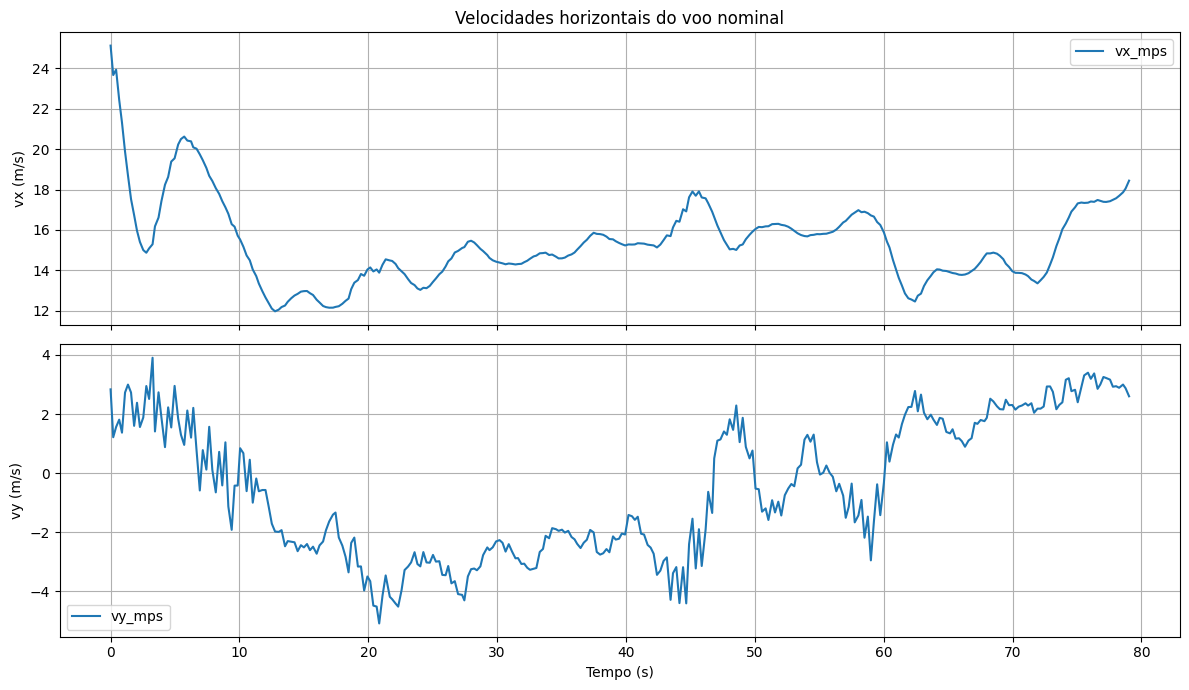

Tempo mínimo: 0.0
Tempo máximo: 79.04201030731201
Duração do voo: 79.04201030731201


In [ ]:
# Visualização inicial do voo nominal

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax[0].plot(df_original["time_s"], df_original["vx_mps"], label="vx_mps")
ax[0].set_ylabel("vx (m/s)")
ax[0].set_title("Velocidades horizontais do voo nominal")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(df_original["time_s"], df_original["vy_mps"], label="vy_mps")
ax[1].set_xlabel("Tempo (s)")
ax[1].set_ylabel("vy (m/s)")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

t_min = df_original["time_s"].min()
t_max = df_original["time_s"].max()

print("Tempo mínimo:", t_min)
print("Tempo máximo:", t_max)
print("Duração do voo:", t_max - t_min)

In [ ]:
# Definição da função do ataque sintético

def inject_velocity_drift_attack(
    df,
    start_time,
    end_time,
    drift_strength_vx=3.0,
    drift_strength_vy=2.0
):
    """
    Cria um ataque sintético defensivo por perturbação suave
    nas velocidades vx_mps e vy_mps dentro de uma janela temporal.
    """

    df_attacked = df.copy()

    # garante que a coluna exista
    df_attacked["synthetic_attack"] = 0

    t = df_attacked["time_s"].to_numpy(dtype=float)
    mask = (t >= start_time) & (t <= end_time)

    if mask.sum() == 0:
        print("Nenhuma amostra encontrada na janela de ataque.")
        return df_attacked

    idx = np.where(mask)[0]
    phase = np.linspace(0, np.pi, len(idx))

    perturb_vx = drift_strength_vx * np.sin(phase)
    perturb_vy = drift_strength_vy * np.sin(phase)

    df_attacked.loc[idx, "vx_mps"] = df_attacked.loc[idx, "vx_mps"].to_numpy() + perturb_vx
    df_attacked.loc[idx, "vy_mps"] = df_attacked.loc[idx, "vy_mps"].to_numpy() + perturb_vy
    df_attacked.loc[idx, "synthetic_attack"] = 1

    return df_attacked

In [ ]:
# Escolha da janela temporal do ataque

start_attack = 40
end_attack = 55

print("Janela do ataque:", start_attack, "até", end_attack, "s")

Janela do ataque: 40 até 55 s


In [ ]:
# Aplicação do ataque sintético

df_attacked = inject_velocity_drift_attack(
    df_original,
    start_time=start_attack,
    end_time=end_attack,
    drift_strength_vx=4.0,
    drift_strength_vy=2.5
)

print("Shape atacado:", df_attacked.shape)
print("Pontos marcados como ataque:", int(df_attacked["synthetic_attack"].sum()))

Shape atacado: (324, 13)
Pontos marcados como ataque: 60


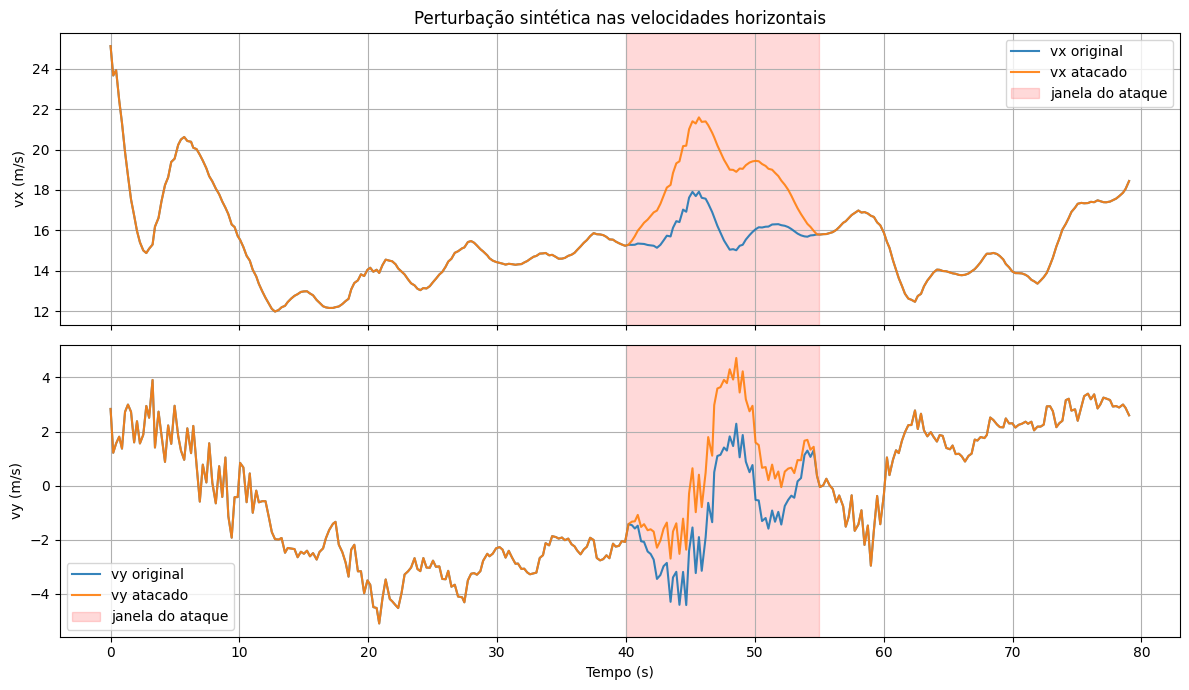

Pontos marcados como ataque: 60


In [ ]:
# Comparação entre o voo original e o voo atacado

fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

ax[0].plot(df_original["time_s"], df_original["vx_mps"], label="vx original", alpha=0.9)
ax[0].plot(df_attacked["time_s"], df_attacked["vx_mps"], label="vx atacado", alpha=0.9)
ax[0].axvspan(start_attack, end_attack, color="red", alpha=0.15, label="janela do ataque")
ax[0].set_ylabel("vx (m/s)")
ax[0].set_title("Perturbação sintética nas velocidades horizontais")
ax[0].grid(True)
ax[0].legend()

ax[1].plot(df_original["time_s"], df_original["vy_mps"], label="vy original", alpha=0.9)
ax[1].plot(df_attacked["time_s"], df_attacked["vy_mps"], label="vy atacado", alpha=0.9)
ax[1].axvspan(start_attack, end_attack, color="red", alpha=0.15, label="janela do ataque")
ax[1].set_xlabel("Tempo (s)")
ax[1].set_ylabel("vy (m/s)")
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()

print("Pontos marcados como ataque:", int(df_attacked["synthetic_attack"].sum()))

In [ ]:
# Criação de uma pasta para salvar o voo sintético

output_dir = DATA_ROOT / f"{flight_name}_synthetic_attack_v1"
output_dir.mkdir(parents=True, exist_ok=True)

print("Pasta de saída:")
print(output_dir)

Pasta de saída:
/content/drive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado/carbonZ_2018-07-30-16-39-00_3_no_failure_synthetic_attack_v1


In [ ]:
# Salvamento do csv atacado

output_csv = output_dir / "flight_consolidated.csv"
df_attacked.to_csv(output_csv, index=False)

print("Arquivo salvo em:")
print(output_csv)
print("Existe?", output_csv.exists())

Arquivo salvo em:
/content/drive/MyDrive/datasets/ALFA/processed_csv/processed_higienizado/carbonZ_2018-07-30-16-39-00_3_no_failure_synthetic_attack_v1/flight_consolidated.csv
Existe? True


In [ ]:
# Resumo da simulação

print("Voo base:", flight_name)
print("Tempo inicial do ataque:", start_attack)
print("Tempo final do ataque:", end_attack)
print("Número de amostras atacadas:", int(df_attacked["synthetic_attack"].sum()))

Voo base: carbonZ_2018-07-30-16-39-00_3_no_failure
Tempo inicial do ataque: 40
Tempo final do ataque: 55
Número de amostras atacadas: 60


## Detector de referência: jerk

Esta parte fica como referência metodológica.  
Ela mostra que um detector puramente temporal consegue captar transientes, mas não é o melhor resultado final.

In [ ]:
# Cálculo da velocidade escalar

df_attacked["v_mps"] = np.sqrt(
    df_attacked["vx_mps"]**2 + df_attacked["vy_mps"]**2
)

df_attacked[["time_s", "v_mps"]].head()

,time_s,v_mps
0,0.000000,25.287011
1,0.205602,23.701517
2,0.428924,23.986927
3,0.669768,22.509629
4,0.885041,21.365321


In [ ]:
# Cálculo do passo de tempo

df_attacked["dt"] = df_attacked["time_s"].diff()

print("dt stats:")
print(df_attacked["dt"].describe())

dt stats:
count    323.000000
mean       0.244712
std        0.027202
min        0.157579
25%        0.227680
50%        0.244901
75%        0.262313
max        0.325988
Name: dt, dtype: float64


In [ ]:
# Cálculo da aceleração

df_attacked["acc_mps2"] = df_attacked["v_mps"].diff() / df_attacked["dt"]

df_attacked[["time_s", "acc_mps2"]].head()

,time_s,acc_mps2
0,0.000000,NaN
1,0.205602,-7.711457
2,0.428924,1.278025
3,0.669768,-6.133831
4,0.885041,-5.315603


In [ ]:
# Limpeza de valores inválidos

df_attacked = df_attacked.replace([np.inf, -np.inf], np.nan)
df_attacked = df_attacked.dropna(subset=["acc_mps2"]).copy()

print("Shape após limpeza:", df_attacked.shape)

Shape após limpeza: (323, 16)


In [ ]:
# Cálculo do jerk

df_attacked["jerk_mps3"] = df_attacked["acc_mps2"].diff() / df_attacked["dt"]

df_attacked[["time_s", "jerk_mps3"]].head()

,time_s,jerk_mps3
1,0.205602,NaN
2,0.428924,40.253557
3,0.669768,-30.774479
4,0.885041,3.800877
5,1.121899,-0.703741


In [ ]:
# Limpeza do jerk

df_attacked = df_attacked.replace([np.inf, -np.inf], np.nan)
df_attacked = df_attacked.dropna(subset=["jerk_mps3"]).copy()

print("Shape após jerk:", df_attacked.shape)

Shape após jerk: (322, 17)


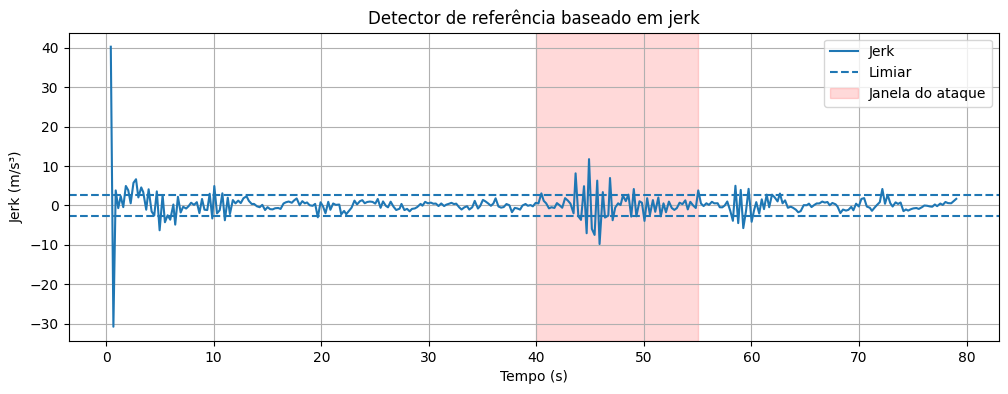

Pontos anômalos pelo jerk: 54


In [ ]:
# Visualização do jerk e detecção pontual

median_jerk = df_attacked["jerk_mps3"].median()
mad_jerk = np.median(np.abs(df_attacked["jerk_mps3"] - median_jerk))
threshold_jerk = median_jerk + 3 * mad_jerk

df_attacked["anomaly_jerk"] = (
    np.abs(df_attacked["jerk_mps3"]) > threshold_jerk
).astype(int)

plt.figure(figsize=(12, 4))
plt.plot(df_attacked["time_s"], df_attacked["jerk_mps3"], label="Jerk")
plt.axhline(threshold_jerk, linestyle="--", label="Limiar")
plt.axhline(-threshold_jerk, linestyle="--")
plt.axvspan(start_attack, end_attack, color="red", alpha=0.15, label="Janela do ataque")
plt.xlabel("Tempo (s)")
plt.ylabel("Jerk (m/s³)")
plt.title("Detector de referência baseado em jerk")
plt.grid(True)
plt.legend()
plt.show()

print("Pontos anômalos pelo jerk:", int(df_attacked["anomaly_jerk"].sum()))

In [ ]:
# Expansão temporal simples do detector de referência

window = 0.5

df_attacked["predicted_attack_jerk"] = 0

for t in df_attacked.loc[df_attacked["anomaly_jerk"] == 1, "time_s"]:
    mask = (
        (df_attacked["time_s"] >= t - window) &
        (df_attacked["time_s"] <= t + window)
    )
    df_attacked.loc[mask, "predicted_attack_jerk"] = 1

df_eval_jerk = df_attacked.copy()
df_eval_jerk["ground_truth_attack"] = df_eval_jerk["synthetic_attack"].astype(int)
df_eval_jerk["predicted_attack"] = df_eval_jerk["predicted_attack_jerk"].astype(int)

y_true_j = df_eval_jerk["ground_truth_attack"].to_numpy()
y_pred_j = df_eval_jerk["predicted_attack"].to_numpy()

tp_j = int(((y_true_j == 1) & (y_pred_j == 1)).sum())
tn_j = int(((y_true_j == 0) & (y_pred_j == 0)).sum())
fp_j = int(((y_true_j == 0) & (y_pred_j == 1)).sum())
fn_j = int(((y_true_j == 1) & (y_pred_j == 0)).sum())

print("Detector de referência (jerk)")
print("TP =", tp_j)
print("TN =", tn_j)
print("FP =", fp_j)
print("FN =", fn_j)

Detector de referência (jerk)
TP = 37
TN = 191
FP = 71
FN = 23


## Detector final: inconsistência física

A ideia é comparar duas descrições do mesmo movimento:

- velocidade medida diretamente pela telemetria
- velocidade inferida pelo deslocamento espacial entre amostras consecutivas

A diferença entre elas define a inconsistência física local.

In [ ]:
# Detector por inconsistência física
# A ideia é comparar a velocidade medida com a velocidade inferida
# a partir do deslocamento entre amostras consecutivas.

df_phys = df_attacked.copy()

In [ ]:
# Verificação das colunas necessárias

required_cols = ["time_s", "x_m", "y_m", "z_m", "vx_mps", "vy_mps", "vz_mps"]
missing = [c for c in required_cols if c not in df_phys.columns]

if missing:
    raise ValueError(f"Faltam colunas para o detector físico: {missing}")

print("Colunas disponíveis para o detector físico.")

Colunas disponíveis para o detector físico.


In [ ]:
# Velocidade medida em 3D

df_phys["v_measured_mps"] = np.sqrt(
    df_phys["vx_mps"]**2 +
    df_phys["vy_mps"]**2 +
    df_phys["vz_mps"]**2
)

df_phys[["time_s", "v_measured_mps"]].head()

,time_s,v_measured_mps
2,0.428924,23.992704
3,0.669768,22.618490
4,0.885041,21.385229
5,1.121899,20.096255
6,1.349541,18.973127


In [ ]:
# Diferenciais locais de posição e tempo

df_phys["dx"] = df_phys["x_m"].diff()
df_phys["dy"] = df_phys["y_m"].diff()
df_phys["dz"] = df_phys["z_m"].diff()
df_phys["dt_local"] = df_phys["time_s"].diff()

df_phys[["time_s", "dx", "dy", "dz", "dt_local"]].head()

,time_s,dx,dy,dz,dt_local
2,0.428924,NaN,NaN,NaN,NaN
3,0.669768,4.001099,3.047421,2.203804,0.240844
4,0.885041,3.353516,2.625515,2.224880,0.215273
5,1.121899,3.325745,2.717541,2.358459,0.236858
6,1.349541,2.844971,2.460110,2.034019,0.227642


In [ ]:
# Velocidade inferida a partir do deslocamento observado

disp_local = np.sqrt(
    df_phys["dx"]**2 +
    df_phys["dy"]**2 +
    df_phys["dz"]**2
)

df_phys["v_from_disp_mps"] = disp_local / df_phys["dt_local"]
df_phys["v_from_disp_mps"] = (
    df_phys["v_from_disp_mps"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

df_phys[["time_s", "v_measured_mps", "v_from_disp_mps"]].head(10)

,time_s,v_measured_mps,v_from_disp_mps
2,0.428924,23.992704,0.000000
3,0.669768,22.618490,22.799433
4,0.885041,21.385229,22.321163
5,1.121899,20.096255,20.686621
6,1.349541,18.973127,18.783410
7,1.587583,17.774329,19.972182
8,1.827518,16.890896,15.818647
9,2.050902,16.149437,16.120362
10,2.277161,15.558548,16.709111
11,2.537151,15.233952,15.319155


In [ ]:
# Inconsistência física principal
# Mede a diferença entre a velocidade declarada e a velocidade inferida da trajetória.

df_phys["phys_inconsistency"] = np.abs(
    df_phys["v_measured_mps"] - df_phys["v_from_disp_mps"]
)

df_phys[["time_s", "phys_inconsistency"]].head(10)

,time_s,phys_inconsistency
2,0.428924,23.992704
3,0.669768,0.180943
4,0.885041,0.935934
5,1.121899,0.590366
6,1.349541,0.189716
7,1.587583,2.197852
8,1.827518,1.072249
9,2.050902,0.029075
10,2.277161,1.150563
11,2.537151,0.085203


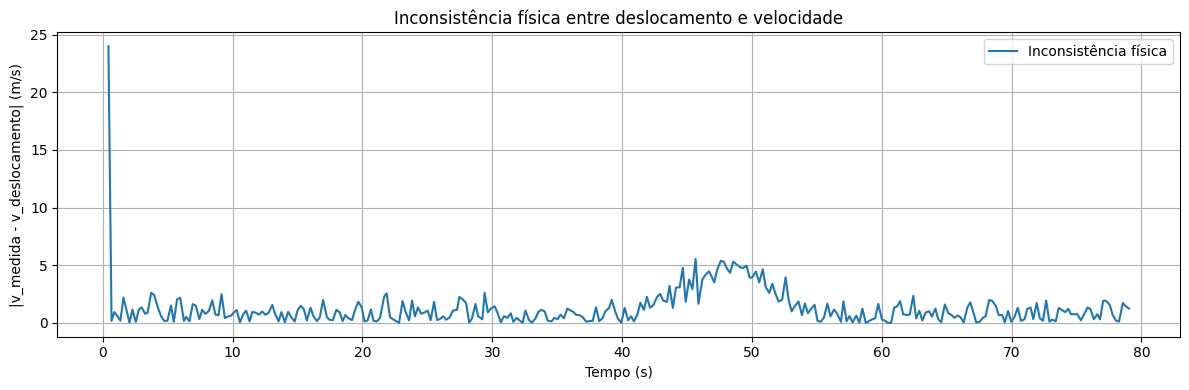

In [ ]:
# Visualização da inconsistência física

plt.figure(figsize=(12, 4))
plt.plot(df_phys["time_s"], df_phys["phys_inconsistency"], label="Inconsistência física")

plt.xlabel("Tempo (s)")
plt.ylabel("|v_medida - v_deslocamento| (m/s)")
plt.title("Inconsistência física entre deslocamento e velocidade")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Limiar do detector físico
# Percentil 90 costuma ser um bom ponto de partida.
# Se detectar pouco, teste 85. Se detectar demais, teste 95.

phys_percentile = 85
threshold_phys = np.nanpercentile(df_phys["phys_inconsistency"].to_numpy(dtype=float), phys_percentile)

print("Percentil usado:", phys_percentile)
print("Threshold físico:", threshold_phys)
print("Máximo da inconsistência:", np.nanmax(df_phys["phys_inconsistency"].to_numpy(dtype=float)))

Percentil usado: 85
Threshold físico: 1.994114212315782
Máximo da inconsistência: 23.99270355250638


In [ ]:
# Pontos anômalos detectados pelo critério físico

df_phys["anomaly_phys"] = (
    df_phys["phys_inconsistency"] > threshold_phys
).astype(int)

print("Anomalias físicas:", int(df_phys["anomaly_phys"].sum()))

Anomalias físicas: 49


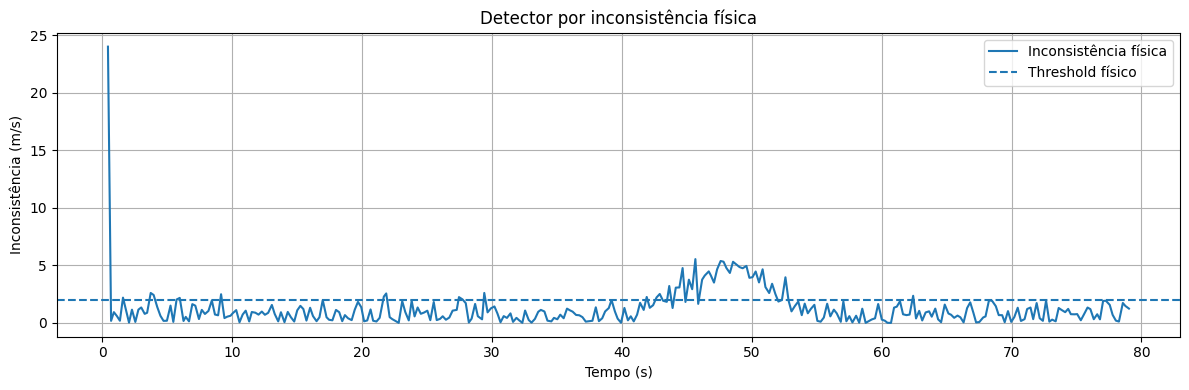

In [ ]:
# Inconsistência física com limiar

plt.figure(figsize=(12, 4))
plt.plot(df_phys["time_s"], df_phys["phys_inconsistency"], label="Inconsistência física")
plt.axhline(threshold_phys, linestyle="--", label="Threshold físico")

plt.xlabel("Tempo (s)")
plt.ylabel("Inconsistência (m/s)")
plt.title("Detector por inconsistência física")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Agrupamento temporal das anomalias físicas

max_gap_phys = 0.6
min_duration_phys = 0.2

anom_times_p = df_phys.loc[df_phys["anomaly_phys"] == 1, "time_s"].to_numpy()

candidate_events_p = []

if len(anom_times_p) > 0:
    start_evt = anom_times_p[0]
    prev_t = anom_times_p[0]

    for t in anom_times_p[1:]:
        if (t - prev_t) <= max_gap_phys:
            prev_t = t
        else:
            candidate_events_p.append((start_evt, prev_t))
            start_evt = t
            prev_t = t

    candidate_events_p.append((start_evt, prev_t))

print("Eventos físicos candidatos:")
for s, e in candidate_events_p:
    print(f"inicio: {s:.2f}s  fim: {e:.2f}s  duracao: {e-s:.2f}s")

Eventos físicos candidatos:
inicio: 0.43s  fim: 0.43s  duracao: 0.00s
inicio: 1.59s  fim: 1.59s  duracao: 0.00s
inicio: 3.72s  fim: 3.95s  duracao: 0.22s
inicio: 5.71s  fim: 5.96s  duracao: 0.24s
inicio: 9.14s  fim: 9.14s  duracao: 0.00s
inicio: 21.67s  fim: 21.85s  duracao: 0.18s
inicio: 27.46s  fim: 27.73s  duracao: 0.27s
inicio: 29.40s  fim: 29.40s  duracao: 0.00s
inicio: 39.20s  fim: 39.20s  duracao: 0.00s
inicio: 41.91s  fim: 41.91s  duracao: 0.00s
inicio: 42.67s  fim: 42.92s  duracao: 0.25s
inicio: 43.65s  fim: 51.82s  duracao: 8.17s
inicio: 52.59s  fim: 52.59s  duracao: 0.00s
inicio: 62.43s  fim: 62.43s  duracao: 0.00s


In [ ]:
# Filtragem por duração mínima

filtered_events_p = [
    (s, e) for s, e in candidate_events_p if (e - s) >= min_duration_phys
]

print("Eventos físicos filtrados:")
for s, e in filtered_events_p:
    print(f"inicio: {s:.2f}s  fim: {e:.2f}s  duracao: {e-s:.2f}s")

Eventos físicos filtrados:
inicio: 3.72s  fim: 3.95s  duracao: 0.22s
inicio: 5.71s  fim: 5.96s  duracao: 0.24s
inicio: 27.46s  fim: 27.73s  duracao: 0.27s
inicio: 42.67s  fim: 42.92s  duracao: 0.25s
inicio: 43.65s  fim: 51.82s  duracao: 8.17s


In [ ]:
# Predição temporal final do detector físico

df_phys["predicted_attack_phys"] = 0

for s, e in filtered_events_p:
    mask = (df_phys["time_s"] >= s) & (df_phys["time_s"] <= e)
    df_phys.loc[mask, "predicted_attack_phys"] = 1

print(df_phys["predicted_attack_phys"].value_counts())

predicted_attack_phys
0    280
1     42
Name: count, dtype: int64


In [ ]:
# Avaliação do detector físico

df_eval_p = df_phys.copy()

if "synthetic_attack" not in df_eval_p.columns:
    df_eval_p["ground_truth_attack"] = (
        (df_eval_p["time_s"] >= start_attack) & (df_eval_p["time_s"] <= end_attack)
    ).astype(int)
else:
    df_eval_p["ground_truth_attack"] = df_eval_p["synthetic_attack"].astype(int)

df_eval_p["predicted_attack"] = df_phys["predicted_attack_phys"].astype(int)

df_eval_p[["time_s", "ground_truth_attack", "predicted_attack"]].head(10)

,time_s,ground_truth_attack,predicted_attack
2,0.428924,0,0
3,0.669768,0,0
4,0.885041,0,0
5,1.121899,0,0
6,1.349541,0,0
7,1.587583,0,0
8,1.827518,0,0
9,2.050902,0,0
10,2.277161,0,0
11,2.537151,0,0


In [ ]:
# Matriz de confusão e métricas do detector físico

y_true_p = df_eval_p["ground_truth_attack"].to_numpy()
y_pred_p = df_eval_p["predicted_attack"].to_numpy()

tp_p = int(((y_true_p == 1) & (y_pred_p == 1)).sum())
tn_p = int(((y_true_p == 0) & (y_pred_p == 0)).sum())
fp_p = int(((y_true_p == 0) & (y_pred_p == 1)).sum())
fn_p = int(((y_true_p == 1) & (y_pred_p == 0)).sum())

precision_p = tp_p / (tp_p + fp_p) if (tp_p + fp_p) > 0 else 0.0
recall_p = tp_p / (tp_p + fn_p) if (tp_p + fn_p) > 0 else 0.0
specificity_p = tn_p / (tn_p + fp_p) if (tn_p + fp_p) > 0 else 0.0
accuracy_p = (tp_p + tn_p) / (tp_p + tn_p + fp_p + fn_p) if (tp_p + tn_p + fp_p + fn_p) > 0 else 0.0
f1_p = 2 * precision_p * recall_p / (precision_p + recall_p) if (precision_p + recall_p) > 0 else 0.0

print("TP =", tp_p)
print("TN =", tn_p)
print("FP =", fp_p)
print("FN =", fn_p)
print(f"Acurácia      : {accuracy_p:.4f}")
print(f"Precisão      : {precision_p:.4f}")
print(f"Recall        : {recall_p:.4f}")
print(f"Especificidade: {specificity_p:.4f}")
print(f"F1-score      : {f1_p:.4f}")

TP = 36
TN = 256
FP = 6
FN = 24
Acurácia      : 0.9068
Precisão      : 0.8571
Recall        : 0.6000
Especificidade: 0.9771
F1-score      : 0.7059


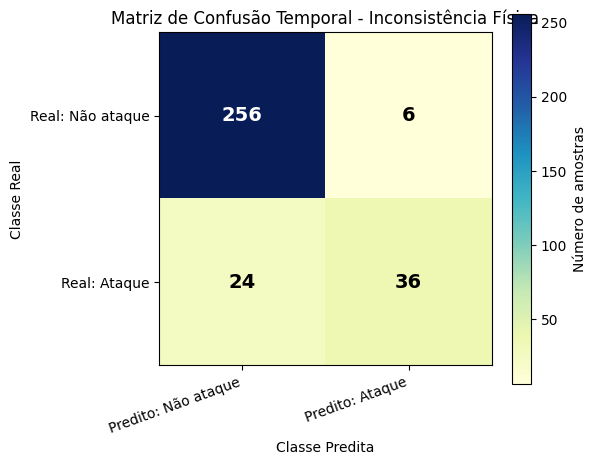

In [ ]:
# Matriz de confusão do detector físico

cm_p = np.array([
    [tn_p, fp_p],
    [fn_p, tp_p]
])

labels_x = ["Predito: Não ataque", "Predito: Ataque"]
labels_y = ["Real: Não ataque", "Real: Ataque"]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_p, cmap="YlGnBu")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels_x)
ax.set_yticklabels(labels_y)

plt.setp(ax.get_xticklabels(), rotation=20, ha="right")

for i in range(2):
    for j in range(2):
        color = "white" if cm_p[i, j] > cm_p.max() / 2 else "black"
        ax.text(
            j, i, cm_p[i, j],
            ha="center", va="center",
            fontsize=14, fontweight="bold", color=color
        )

ax.set_title("Matriz de Confusão Temporal - Inconsistência Física")
ax.set_xlabel("Classe Predita")
ax.set_ylabel("Classe Real")

cbar = plt.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Número de amostras", rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
# Comparação resumida entre o detector de referência e o detector físico

recall_j = tp_j / (tp_j + fn_j) if (tp_j + fn_j) > 0 else 0.0
precision_j = tp_j / (tp_j + fp_j) if (tp_j + fp_j) > 0 else 0.0

print("Resumo comparativo")
print("------------------")
print(f"Jerk  -> TP={tp_j}, TN={tn_j}, FP={fp_j}, FN={fn_j}, Recall={recall_j:.4f}, Precisão={precision_j:.4f}")
print(f"Físico-> TP={tp_p}, TN={tn_p}, FP={fp_p}, FN={fn_p}, Recall={recall_p:.4f}, Precisão={precision_p:.4f}")

Resumo comparativo
------------------
Jerk  -> TP=37, TN=191, FP=71, FN=23, Recall=0.6167, Precisão=0.3426
Físico-> TP=36, TN=256, FP=6, FN=24, Recall=0.6000, Precisão=0.8571
